<h2 style="color:green" align="center">Predicting if a person would buy life insurnace based on his age using logistic regression</h2>

Above is a binary logistic regression problem as there are only two possible outcomes (i.e. if person buys insurance or he/she doesn't). 

In [61]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [62]:
df = pd.read_csv("insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


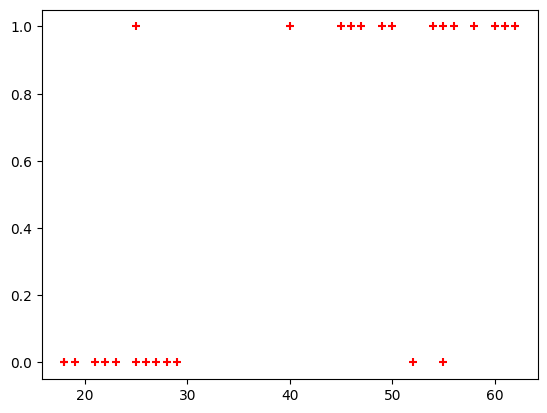

In [63]:
plt.scatter(df.age,df.bought_insurance,marker='+',color='red')

In [64]:
from sklearn.model_selection import train_test_split

In [65]:
X_train, X_test, y_train, y_test = train_test_split(df[['age']],df.bought_insurance,train_size=0.8)

In [66]:
X_test

,age
12,27
18,19
21,26
4,46
22,40
5,56


In [67]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [68]:
model.fit(X_train, y_train)

LogisticRegression()

In [69]:
X_test

,age
12,27
18,19
21,26
4,46
22,40
5,56


In [70]:
y_predicted = model.predict(X_test)
y_predicted

array([0, 0, 0, 1, 0, 1])

In [71]:
model.predict_proba(X_test)

array([[0.82431258, 0.17568742],
       [0.92357923, 0.07642077],
       [0.84078938, 0.15921062],
       [0.33152776, 0.66847224],
       [0.50208389, 0.49791611],
       [0.13193221, 0.86806779]])

In [72]:
model.score(X_test,y_test)

0.8333333333333334

In [73]:
y_predicted

array([0, 0, 0, 1, 0, 1])

In [74]:
X_test

,age
12,27
18,19
21,26
4,46
22,40
5,56


**model.coef_ indicates value of m in y=m*x + b equation**

In [75]:
model.coef_

array([[0.11826983]])

**model.intercept_ indicates value of b in y=m*x + b equation**

In [76]:
model.intercept_

array([-4.73912875])

**Lets defined sigmoid function now and do the math with hand**

In [77]:
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [78]:
def prediction_function(age):
    z = 0.042 * age - 1.53 # 0.04150133 ~ 0.042 and -1.52726963 ~ -1.53
    y = sigmoid(z)
    return y

In [79]:
age = 35
prediction_function(age)

0.4850044983805899

**0.485 is less than 0.5 which means person with 35 age will *not* buy insurance**

In [80]:
age = 43
prediction_function(age)

0.568565299077705

**0.485 is more than 0.5 which means person with 43 will buy the insurance**

<h2 style="color:purple">Exercise</h2>

Download employee retention dataset from here: https://www.kaggle.com/giripujar/hr-analytics. 
1. Now do some exploratory data analysis to figure out which variables have direct and clear impact on employee retention (i.e. whether they leave the company or continue to work)
2. Plot bar charts showing impact of employee salaries on retention
3. Plot bar charts showing corelation between department and employee retention
4. Now build logistic regression model using variables that were narrowed down in step 1
5. Measure the accuracy of the model

In [81]:
import pandas as pd
dfhr = pd.read_csv("Exercise/HR_comma_sep.csv")
dfhr

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


<Axes: xlabel='promotion_last_5years'>

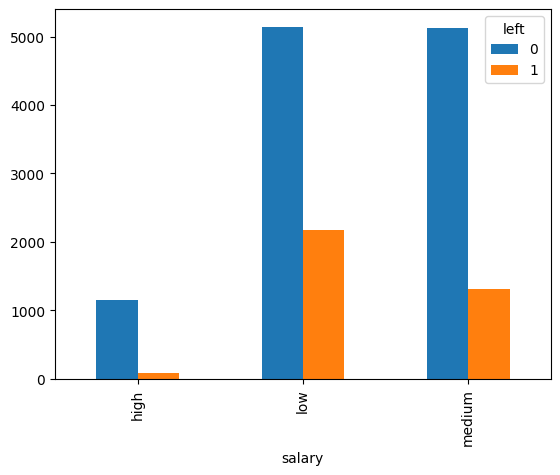

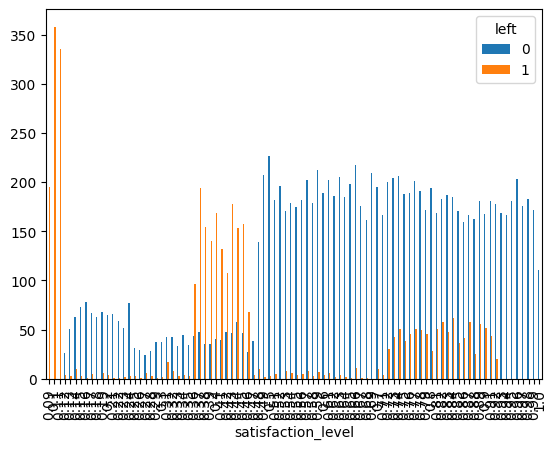

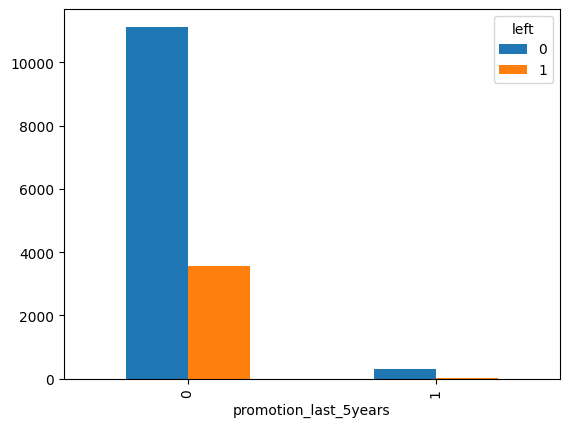

In [82]:
# plot satisfaction_level vs left
# plt.scatter(dfhr.satisfaction_level,dfhr.left,marker='+',color='red')
# plot last_evaluation vs left
# plt.scatter(dfhr.last_evaluation,dfhr.left,marker='+',color='purple')
# plot number_project vs left
#plt.scatter(dfhr.number_project,dfhr.left,marker='+',color='blue')
# plot average_montly_hours vs left
# plt.scatter(dfhr.average_montly_hours,dfhr.left,marker='+',color='green')
# plot time_spend_company vs left
# plt.scatter(dfhr.time_spend_company,dfhr.left,marker='+',color='orange')
# plot Work_accident vs left
# plt.scatter(dfhr.Work_accident,dfhr.left,marker='+',color='orange')
# plot promotion_last_5years vs left
# plt.scatter(dfhr.promotion_last_5years,dfhr.left,marker='+',color='orange')
# plot salary vs left in cross tab using plt 
pd.crosstab(dfhr.salary,dfhr.left).plot(kind='bar')
# plot satisfaction_level vs left in cross tab using plt
pd.crosstab(dfhr.satisfaction_level,dfhr.left).plot(kind='bar')
# plot promotion_last_5years vs left in cross tab using plt
pd.crosstab(dfhr.promotion_last_5years,dfhr.left).plot(kind='bar')
#plt.scatter(dfhr.salary,dfhr.left,marker='+',color='orange')

In [83]:
subdfhr = dfhr[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]
subdfhr

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low
...,...,...,...,...
14994,0.40,151,0,low
14995,0.37,160,0,low
14996,0.37,143,0,low
14997,0.11,280,0,low


In [84]:
# generate x_train, x_test, y_train, y_test using train_test_split
# import train_test_split from sklearn.model_selection
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(subdfhr,dfhr.left,train_size=0.8)

In [85]:
X_train

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
8669,0.90,144,0,low
2243,0.92,240,0,low
11267,0.70,110,0,low
8060,0.75,189,0,low
2750,0.91,255,0,low
...,...,...,...,...
4564,0.52,108,0,medium
3109,0.67,237,0,medium
8714,0.20,190,0,low
5760,0.98,197,0,low


In [86]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# use LabelEncoder to convert salary to a number
le = LabelEncoder()
X_train['salary'] = le.fit_transform(X_train['salary'])
X_test['salary'] = le.transform(X_test['salary'])
# convert salary in X_train to a number using one hot encoding
column_transformer = ColumnTransformer(
    transformers=[
        ('salary', OneHotEncoder(), ['salary'])
    ],
    remainder='passthrough'
)

X_train_transformed = column_transformer.fit_transform(X_train)
X_test_transformed = column_transformer.transform(X_test)


In [87]:
X_train_transformed

array([[0.00e+00, 1.00e+00, 0.00e+00, 9.00e-01, 1.44e+02, 0.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 9.20e-01, 2.40e+02, 0.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 7.00e-01, 1.10e+02, 0.00e+00],
       ...,
       [0.00e+00, 1.00e+00, 0.00e+00, 2.00e-01, 1.90e+02, 0.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 9.80e-01, 1.97e+02, 0.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 1.70e-01, 2.61e+02, 0.00e+00]])

In [88]:
# use LogisticRegression to train the model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression() # create a model
model.fit(X_train_transformed, y_train) # train the model   


LogisticRegression()

In [89]:
# use the model to score the model
model.score(X_test_transformed,y_test)

0.769